In [77]:
import sys
import tensorflow as tf
import keras

print(sys.version)
print(tf.__version__)
print(keras.__version__)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
2.21.0
3.14.1


In [78]:
# =========================
# CELL 1: IMPORTS
# =========================
# Syfte:
# Vi importerar bibliotek för:
# - datahantering
# - visualisering
# - preprocessing
# - train/test split
# - ANN med TensorFlow/Keras
# - utvärdering

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

sns.set(style="whitegrid")

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [79]:
Path.cwd(), list(Path.cwd().glob("*"))

(WindowsPath('c:/Users/spiri/ws/mental-health-prediction/notebooks'),
 [WindowsPath('c:/Users/spiri/ws/mental-health-prediction/notebooks/01_emmy_data_loading_and_eda.ipynb'),
  WindowsPath('c:/Users/spiri/ws/mental-health-prediction/notebooks/01_spirit_data.ipynb')])

In [80]:
# =========================
# CELL 2: LOAD DATA
# =========================
# Notebooken ligger i /notebooks
# CSV-filen ligger i /data
# Därför använder vi ../data/filnamn

from pathlib import Path
import pandas as pd

data_path = Path("../data/Student Depression Dataset.csv")

print("Nuvarande notebook-mapp:", Path.cwd())
print("Söker efter filen här:", data_path.resolve())
print("Finns filen?", data_path.exists())

df = pd.read_csv(data_path)

df.head()

Nuvarande notebook-mapp: c:\Users\spiri\ws\mental-health-prediction\notebooks
Söker efter filen här: C:\Users\spiri\ws\mental-health-prediction\data\Student Depression Dataset.csv
Finns filen? True


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [81]:
# =========================
# CELL 3: BASIC OVERVIEW
# =========================
# Syfte:
# Innan vi bygger ANN måste vi förstå:
# - antal rader/kolumner
# - datatyper
# - saknade värden
# - vilka variabler som finns

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

df.describe(include="all").T

Shape: (27901, 18)

Columns:
['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  str    
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  str    
 4   Profession                             27901 non-null  str    
 5   Academic Pressure                      27901 non-null  float64
 6   Work P

Financial Stress                         3
id                                       0
Gender                                   0
Age                                      0
Profession                               0
City                                     0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Academic Pressure                        0
Job Satisfaction                         0
Sleep Duration                           0
Degree                                   0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,27901.0,NaN,NaN,NaN,70442.149421,40641.175216,2.0,35039.0,70684.0,105818.0,140699.0
Gender,27901,2,Male,15547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,27901.0,NaN,NaN,NaN,25.8223,4.905687,18.0,21.0,25.0,30.0,59.0
City,27901,52,Kalyan,1570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,27901,14,Student,27870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic Pressure,27901.0,NaN,NaN,NaN,3.141214,1.381465,0.0,2.0,3.0,4.0,5.0
Work Pressure,27901.0,NaN,NaN,NaN,0.00043,0.043992,0.0,0.0,0.0,0.0,5.0
CGPA,27901.0,NaN,NaN,NaN,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,NaN,NaN,NaN,2.943837,1.361148,0.0,2.0,3.0,4.0,5.0
Job Satisfaction,27901.0,NaN,NaN,NaN,0.000681,0.044394,0.0,0.0,0.0,0.0,4.0


Depression
1    16336
0    11565
Name: count, dtype: int64
Depression
1    0.585499
0    0.414501
Name: proportion, dtype: float64


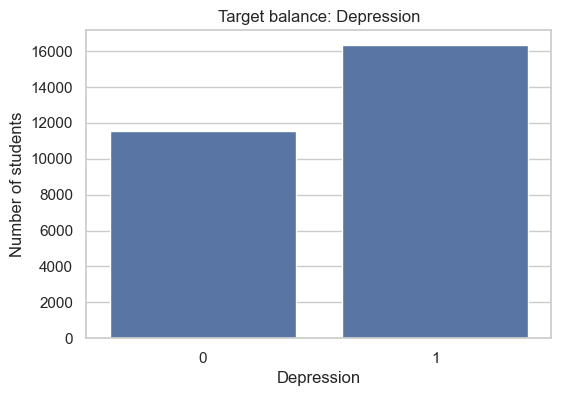

In [82]:
# =========================
# CELL 4: TARGET VARIABLE
# =========================
# Frågeställning:
# Vad är det modellen ska förutsäga?
#
# Här antar vi att target heter "Depression".
# Om kolumnen heter något annat, byt target_col.

target_col = "Depression"

print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col)
plt.title("Target balance: Depression")
plt.xlabel("Depression")
plt.ylabel("Number of students")
plt.show()

In [83]:
# =========================
# CELL 5: CLEAN TARGET
# =========================
# Syfte:
# ANN behöver numeriska labels.
#
# Vi gör Depression till:
# 1 = depression/risk
# 0 = ingen depression/risk

df_model = df.copy()

print("Before:")
print(df_model[target_col].unique())

# Robust mapping om värdena är Yes/No
if df_model[target_col].dtype == "object":
    df_model[target_col] = (
        df_model[target_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "yes": 1,
            "no": 0,
            "1": 1,
            "0": 0,
            "true": 1,
            "false": 0
        })
    )

print("After:")
print(df_model[target_col].value_counts(dropna=False))

Before:
[1 0]
After:
Depression
1    16336
0    11565
Name: count, dtype: int64


In [84]:
# =========================
# CELL 6: DROP MISSING TARGET
# =========================
# Syfte:
# Vi kan inte träna supervised learning om facit saknas.

df_model = df_model.dropna(subset=[target_col]).copy()

print("Shape after dropping missing target:", df_model.shape)

Shape after dropping missing target: (27901, 18)


Numeric columns: ['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']


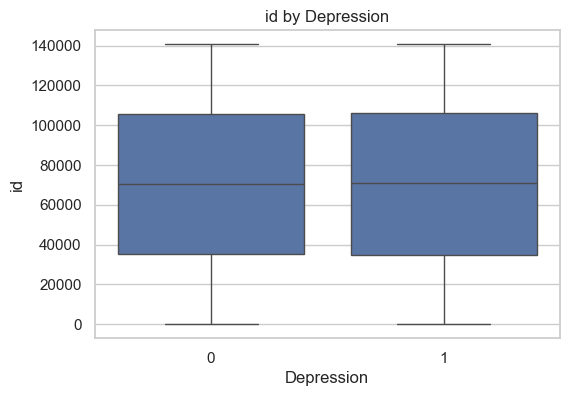

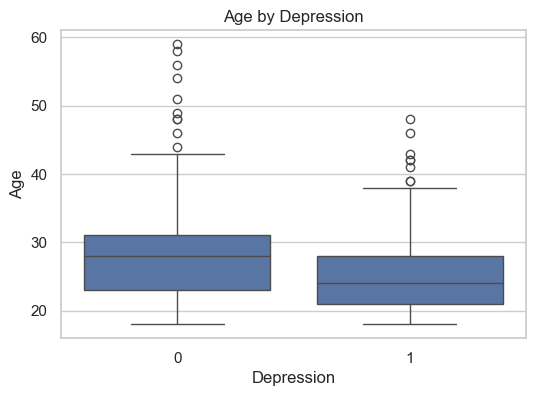

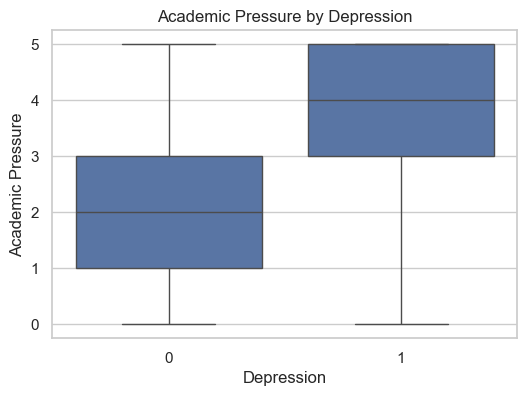

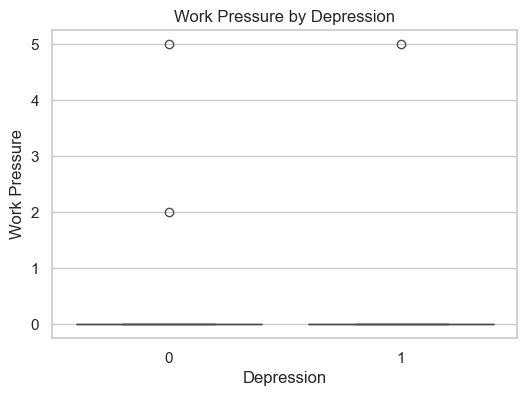

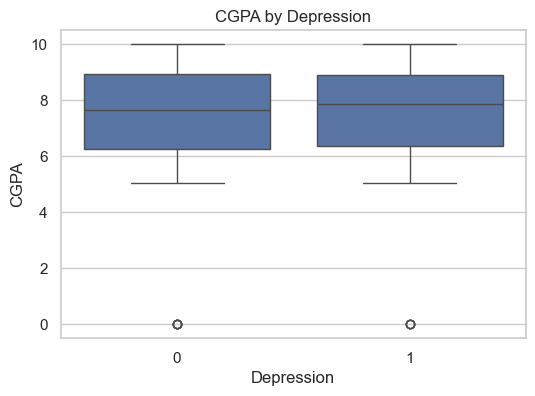

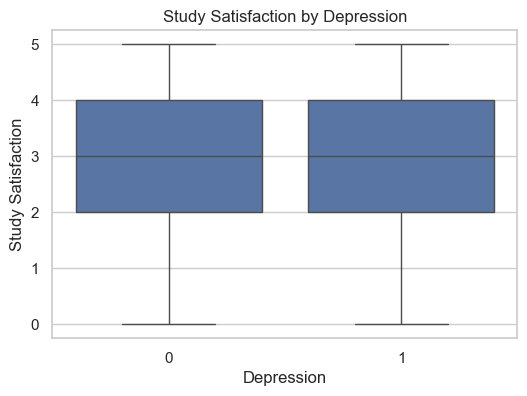

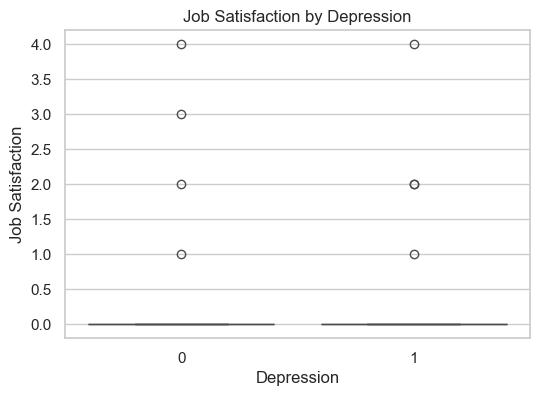

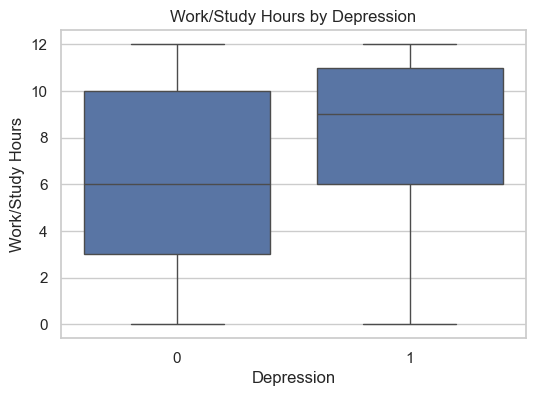

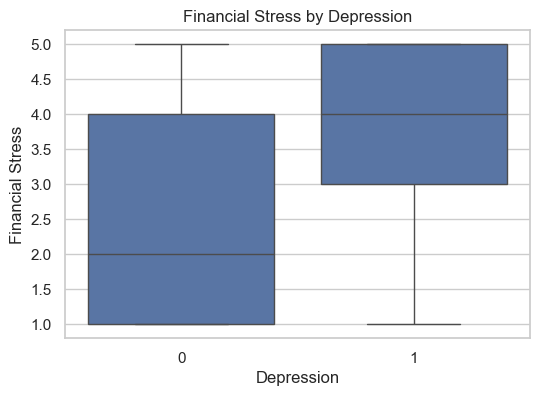

In [85]:
# =========================
# CELL 7: NUMERIC EDA
# =========================
# Frågeställning:
# Vilka numeriska variabler verkar skilja studenter med och utan depression?
#
# Logik:
# Om vissa variabler skiljer grupperna kan de vara viktiga input-neuroner.

numeric_cols = df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != target_col]

print("Numeric columns:", numeric_cols)

for col in numeric_cols[:12]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_model, x=target_col, y=col)
    plt.title(f"{col} by Depression")
    plt.xlabel("Depression")
    plt.ylabel(col)
    plt.show()

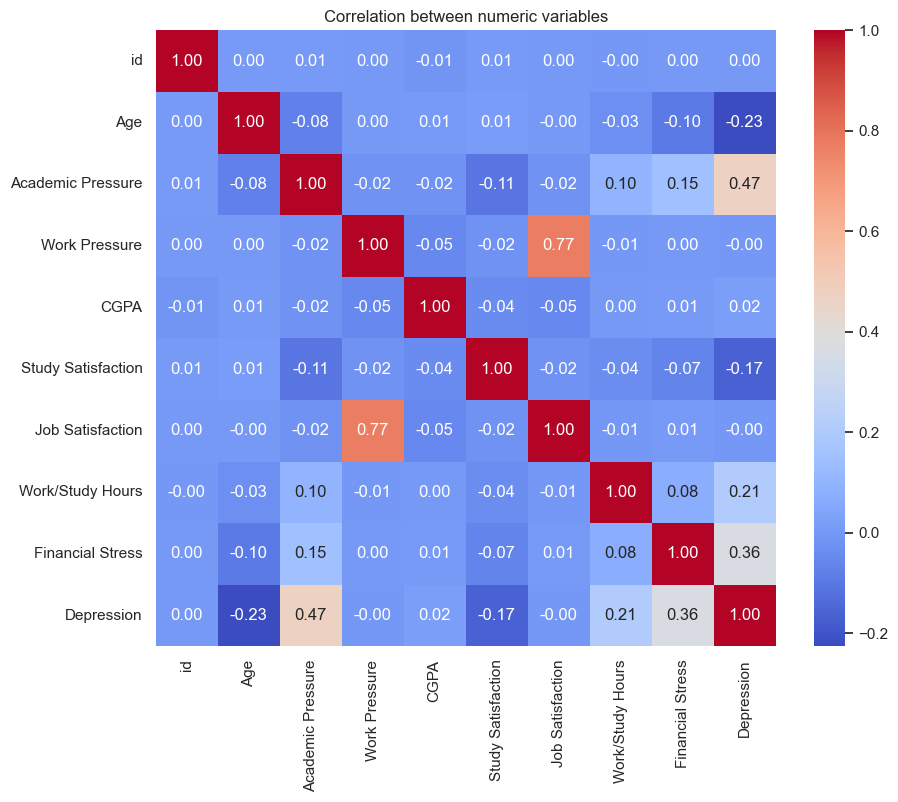

Depression            1.000000
Academic Pressure     0.474835
Financial Stress      0.363591
Work/Study Hours      0.208563
CGPA                  0.022210
id                    0.000923
Work Pressure        -0.003351
Job Satisfaction     -0.003482
Study Satisfaction   -0.167971
Age                  -0.226422
Name: Depression, dtype: float64

In [86]:
# =========================
# CELL 8: CORRELATION HEATMAP
# =========================
# Frågeställning:
# Vilka numeriska variabler hänger ihop?
#
# Logik:
# Hög korrelation kan betyda att flera variabler bär liknande information.
# ANN klarar ofta korrelerade features, men det hjälper oss förstå datan.

corr = df_model[numeric_cols + [target_col]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between numeric variables")
plt.show()

corr[target_col].sort_values(ascending=False)

In [87]:
# =========================
# CELL 9: CLEAN PREPROCESSING
# =========================

target_col = "Depression"

# Kopia
df_model = df.copy()

# Ta bort id
df_model = df_model.drop(columns=["id"])

# Ta bort missing rows
df_model = df_model.dropna()

# One-hot encoding
df_encoded = pd.get_dummies(
    df_model,
    drop_first=True,
    dtype="float32"
)

print(df_encoded.shape)

display(df_encoded.head())

(27898, 110)


,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression,Gender_Male,...,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD,Have you ever had suicidal thoughts ?_Yes,Family History of Mental Illness_Yes
0,33.0,5.0,0.0,8.97,2.0,0.0,3.0,1.0,1,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,24.0,2.0,0.0,5.90,5.0,0.0,3.0,2.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,31.0,3.0,0.0,7.03,5.0,0.0,9.0,1.0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,28.0,3.0,0.0,5.59,2.0,0.0,4.0,5.0,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,25.0,4.0,0.0,8.13,3.0,0.0,1.0,1.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [88]:
X = df_encoded.drop(columns=[target_col]).astype("float32")
y = df_encoded[target_col].astype("float32")

In [89]:
# =========================
# CELL 11: TRAIN/TEST SPLIT
# =========================
# Frågeställning:
# Hur testar vi modellen på ett rättvist sätt?
#
# Logik:
# Train = modellen lär sig
# Test = modellen får ny data den inte sett tidigare
#
# stratify=y gör att samma andel depression/icke-depression finns i både train och test.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target balance:")
print(y_train.value_counts(normalize=True))

print("\nTest target balance:")
print(y_test.value_counts(normalize=True))

Train shape: (22318, 109)
Test shape: (5580, 109)

Train target balance:
Depression
1.0    0.585536
0.0    0.414464
Name: proportion, dtype: float64

Test target balance:
Depression
1.0    0.585484
0.0    0.414516
Name: proportion, dtype: float64


In [90]:
# =========================
# CELL 12: SCALE FEATURES
# =========================
# Frågeställning:
# Varför behöver ANN standardisering?
#
# Logik:
# Neural networks lär sig bättre när input ligger på liknande skala.
# Age, CGPA och Financial Stress har olika skalor.
# StandardScaler gör variablerna jämförbara.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype("float32")
X_test_scaled = scaler.transform(X_test).astype("float32")

y_train_np = y_train.to_numpy().astype("float32")
y_test_np = y_test.to_numpy().astype("float32")

print("Processed train shape:", X_train_scaled.shape)
print("Processed test shape:", X_test_scaled.shape)

Processed train shape: (22318, 109)
Processed test shape: (5580, 109)


In [91]:
# =========================
# CELL 12.1: DEBUG DATA TYPES
# =========================
# Frågeställning:
# Är alla features verkligen numeriska?
#
# Logik:
# TensorFlow fungerar bäst med float32.
# Bool/object kan skapa problem.

print(X.dtypes.value_counts())

print("\nNon-numeric columns:")
print(X.select_dtypes(exclude=["number"]).columns.tolist())

float32    109
Name: count, dtype: int64

Non-numeric columns:
[]


In [92]:
# =========================
# CELL 12.2: FORCE FLOAT32
# =========================
# Frågeställning:
# Kan vi säkerställa att TensorFlow får rätt datatyp?

X = X.astype("float32")

print(X.dtypes.unique())

[dtype('float32')]


In [93]:
# =========================
# CELL 12.3: DEBUG PREDICTIONS
# =========================
# Frågeställning:
# Ger modellen olika sannolikheter eller samma hela tiden?

sample_probs = ann_baseline.predict(X_test_scaled[:20]).ravel()

print(sample_probs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[0.58884203 0.58884203 0.58884203 0.58884203 0.58884203 0.58884203
 0.58884203 0.58884203 0.58884203 0.58884203 0.58884203 0.58884203
 0.58884203 0.58884203 0.58884203 0.58884203 0.58884203 0.58884203
 0.58884203 0.58884203]


In [94]:
# =========================
# CELL 13: MAJORITY BASELINE
# =========================
# Frågeställning:
# Hur bra blir en modell som bara gissar största klassen?
#
# Logik:
# Om ANN bara får ungefär samma resultat som baseline har den inte lärt sig något.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

majority_class = int(y_train.mode()[0])

baseline_pred = np.full_like(y_test_np, fill_value=majority_class)

print("Majority class:", majority_class)
print("Baseline accuracy:", accuracy_score(y_test_np, baseline_pred))

print(classification_report(y_test_np, baseline_pred, zero_division=0))

Majority class: 1
Baseline accuracy: 0.5854838709677419
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      2313
         1.0       0.59      1.00      0.74      3267

    accuracy                           0.59      5580
   macro avg       0.29      0.50      0.37      5580
weighted avg       0.34      0.59      0.43      5580



In [95]:
# =========================
# CELL 14: EVALUATION FUNCTION
# =========================
# Frågeställning:
# Hur mäter vi om ANN faktiskt lär sig?
#
# Logik:
# Vi vill se:
# - accuracy
# - ROC AUC
# - precision
# - recall
# - F1
# - confusion matrix
#
# ROC AUC nära 0.5 = modellen är ungefär som slump/majoritetsgissning.

def evaluate_ann(model_name, model, X_test_scaled, y_test_np, threshold=0.5):
    y_proba = model.predict(X_test_scaled).ravel()
    y_pred = (y_proba >= threshold).astype(int)

    print(f"===== {model_name} =====")
    print("Threshold:", threshold)
    print("Accuracy:", accuracy_score(y_test_np, y_pred))
    print("ROC AUC:", roc_auc_score(y_test_np, y_proba))

    print("\nPredicted probability summary:")
    print(pd.Series(y_proba).describe())

    print("\nClassification report:")
    print(classification_report(y_test_np, y_pred, zero_division=0))

    cm = confusion_matrix(y_test_np, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No depression", "Depression"],
        yticklabels=["No depression", "Depression"]
    )
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test_np, y_pred),
        "roc_auc": roc_auc_score(y_test_np, y_proba)
    }

In [96]:
# =========================
# CELL 15: BASELINE ANN
# =========================
# Frågeställning:
# Kan ett enkelt neuralt nätverk lära sig mönster som förutsäger depression?
#
# Logik:
# Input layer: tar emot alla features
# Hidden layer 1: lär sig enkla kombinationer
# Hidden layer 2: lär sig mer komplexa kombinationer
# Output layer: sigmoid ger sannolikhet mellan 0 och 1

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

input_dim = X_train_scaled.shape[1]

ann_baseline = Sequential([
    Dense(64, activation="relu", input_shape=(input_dim,)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_baseline.summary()

c:\Users\spiri\ws\mental-health-prediction\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 64)             │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,153 (35.75 KB)

 Trainable params: 9,153 (35.75 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
# =========================
# CELL 15.1: VISUALIZE ANN LOGIC
# =========================
# Frågeställning:
# Hur ser informationsflödet i ANN ut?

from IPython.display import display, Markdown

display(Markdown("""

# ANN Information Flow

## Input Layer
- Age
- Academic Pressure
- Financial Stress
- Sleep Duration
- Diet
- Suicidal Thoughts
- etc...

↓

## Hidden Layer 1
Lär sig enklare kombinationer:
- Stress + lite sömn
- Financial stress + suicidal thoughts

↓

## Hidden Layer 2
Lär sig mer komplexa mönster:
- Riskprofiler
- Kombinationer av psykisk belastning

↓

## Output Layer
Ger sannolikhet:

0 → låg risk depression  
1 → hög risk depression

Exempel:
- 0.12 = låg risk
- 0.87 = hög risk

"""))



# ANN Information Flow

## Input Layer
- Age
- Academic Pressure
- Financial Stress
- Sleep Duration
- Diet
- Suicidal Thoughts
- etc...

↓

## Hidden Layer 1
Lär sig enklare kombinationer:
- Stress + lite sömn
- Financial stress + suicidal thoughts

↓

## Hidden Layer 2
Lär sig mer komplexa mönster:
- Riskprofiler
- Kombinationer av psykisk belastning

↓

## Output Layer
Ger sannolikhet:

0 → låg risk depression  
1 → hög risk depression

Exempel:
- 0.12 = låg risk
- 0.87 = hög risk



In [98]:
# =========================
# CELL 16: TRAIN BASELINE ANN
# =========================
# Frågeställning:
# Blir modellen bättre över epochs?
#
# Logik:
# Om loss sjunker och validation accuracy förbättras lär sig modellen.
# Om allt ligger platt nära 0.58/ROC AUC 0.5 lär sig modellen inte.

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_baseline = ann_baseline.fit(
    X_train_scaled,
    y_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8112 - loss: 0.4132 - val_accuracy: 0.8445 - val_loss: 0.3644
Epoch 2/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8494 - loss: 0.3479 - val_accuracy: 0.8434 - val_loss: 0.3647
Epoch 3/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8529 - loss: 0.3377 - val_accuracy: 0.8443 - val_loss: 0.3672
Epoch 4/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8568 - loss: 0.3306 - val_accuracy: 0.8425 - val_loss: 0.3699
Epoch 5/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8592 - loss: 0.3245 - val_accuracy: 0.8432 - val_loss: 0.3725
Epoch 6/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8616 - loss: 0.3192 - val_accuracy: 0.8423 - val_loss: 0.3760


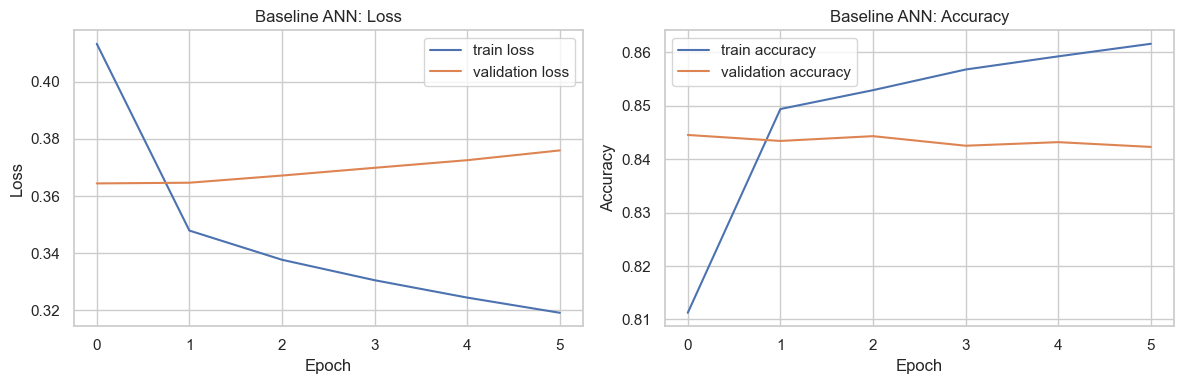

In [99]:
# =========================
# CELL 17: LEARNING CURVES
# =========================
# Frågeställning:
# Lär sig modellen, övertränar den eller fastnar den?
#
# Logik:
# Bra tecken:
# - train loss går ned
# - validation loss går ned
# - accuracy går upp
#
# Dåligt tecken:
# - båda linjerna är helt platta

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history["loss"], label="train loss")
plt.plot(history_baseline.history["val_loss"], label="validation loss")
plt.title("Baseline ANN: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history["accuracy"], label="train accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="validation accuracy")
plt.title("Baseline ANN: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


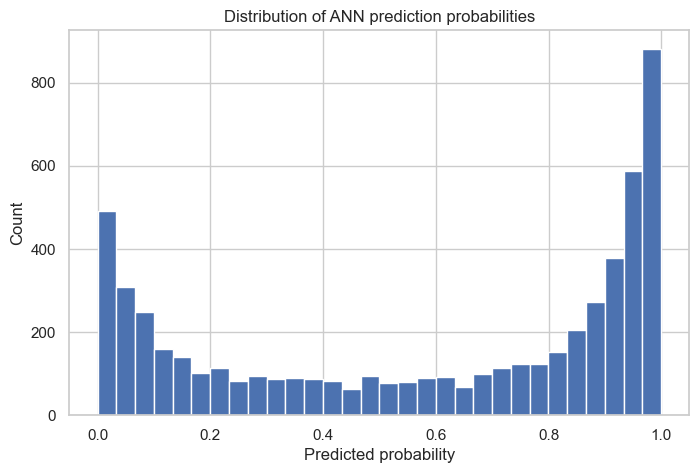

count    5.580000e+03
mean     5.842489e-01
std      3.690474e-01
min      4.129300e-08
25%      1.825813e-01
50%      7.160005e-01
75%      9.387695e-01
max      9.997780e-01
dtype: float64


In [100]:
# =========================
# CELL 17.1: PREDICTION DISTRIBUTION
# =========================
# Frågeställning:
# Ger modellen varierade sannolikheter eller samma hela tiden?

y_probs = ann_baseline.predict(X_test_scaled).ravel()

plt.figure(figsize=(8,5))

plt.hist(y_probs, bins=30)

plt.title("Distribution of ANN prediction probabilities")
plt.xlabel("Predicted probability")
plt.ylabel("Count")

plt.show()

print(pd.Series(y_probs).describe())

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
===== Baseline ANN =====
Threshold: 0.5
Accuracy: 0.839426523297491
ROC AUC: 0.9129325986614829

Predicted probability summary:
count    5.580000e+03
mean     5.842489e-01
std      3.690474e-01
min      4.129300e-08
25%      1.825813e-01
50%      7.160005e-01
75%      9.387695e-01
max      9.997780e-01
dtype: float64

Classification report:
              precision    recall  f1-score   support

         0.0       0.82      0.79      0.80      2313
         1.0       0.85      0.87      0.86      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.83      0.83      5580
weighted avg       0.84      0.84      0.84      5580



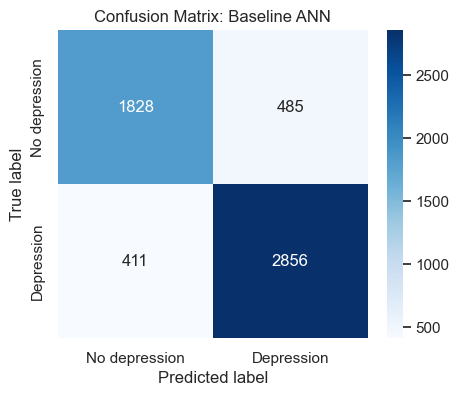

In [101]:
# =========================
# CELL 18: EVALUATE BASELINE ANN
# =========================
# Frågeställning:
# Är ANN bättre än majoritetsmodellen?

ann_results = []

ann_results.append(
    evaluate_ann(
        "Baseline ANN",
        ann_baseline,
        X_test_scaled,
        y_test_np,
        threshold=0.5
    )
)

Class weights: {0: np.float64(1.2063783783783784), 1: np.float64(0.8539179675543311)}
Epoch 1/50


c:\Users\spiri\ws\mental-health-prediction\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8061 - loss: 0.4258 - val_accuracy: 0.8389 - val_loss: 0.3766
Epoch 2/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8478 - loss: 0.3553 - val_accuracy: 0.8394 - val_loss: 0.3718
Epoch 3/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8513 - loss: 0.3449 - val_accuracy: 0.8392 - val_loss: 0.3737
Epoch 4/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8543 - loss: 0.3379 - val_accuracy: 0.8396 - val_loss: 0.3765
Epoch 5/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8563 - loss: 0.3330 - val_accuracy: 0.8387 - val_loss: 0.3805
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
===== ANN with Class Weights =====
Threshold: 0.5
Accuracy: 0.8331541218637993
ROC AUC: 0.9122488890794515

Predicted probability summary:
count    5580.000000
mean        0.542221
std         0.373058
min         0.000545
25%         0.129326
50%         0.629559
75%         0.915669
max         0.999243
dtype: float64

Class

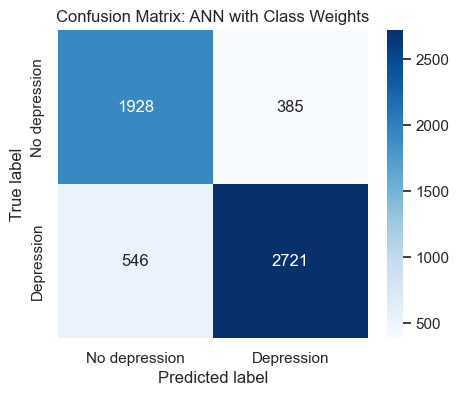

In [102]:
# =========================
# CELL 19: ANN WITH CLASS WEIGHTS
# =========================
# Frågeställning:
# Hjälper det modellen att ta båda klasserna mer seriöst?
#
# Logik:
# Datasetet är inte extremt obalanserat, men 1-klassen är större.
# class_weight gör att modellen inte bara ska välja majoritetsklassen.

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_np.astype(int)
)

class_weight = {
    0: weights[0],
    1: weights[1]
}

print("Class weights:", class_weight)

ann_weighted = Sequential([
    Dense(64, activation="relu", input_shape=(input_dim,)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann_weighted.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_weighted = ann_weighted.fit(
    X_train_scaled,
    y_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1
)

ann_results.append(
    evaluate_ann(
        "ANN with Class Weights",
        ann_weighted,
        X_test_scaled,
        y_test_np,
        threshold=0.5
    )
)

In [103]:
# =========================
# CELL 19.1: REMOVE WEAK FEATURES
# =========================
# Frågeställning:
# Hjälper det att ta bort nästan tomma variabler?
#
# Logik:
# Work Pressure och Job Satisfaction verkar nästan alltid vara 0.
# De kanske bara skapar brus.

weak_features = [
    "Work Pressure",
    "Job Satisfaction"
]

X_reduced = X.drop(columns=weak_features)

print("Original shape:", X.shape)
print("Reduced shape:", X_reduced.shape)

Original shape: (27898, 109)
Reduced shape: (27898, 107)



175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
===== Weighted ANN threshold 0.3 =====
Threshold: 0.3
Accuracy: 0.8383512544802867
ROC AUC: 0.9122488890794515

Predicted probability summary:
count    5580.000000
mean        0.542221
std         0.373058
min         0.000545
25%         0.129326
50%         0.629559
75%         0.915669
max         0.999243
dtype: float64

Classification report:
              precision    recall  f1-score   support

         0.0       0.86      0.73      0.79      2313
         1.0       0.83      0.91      0.87      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.82      0.83      5580
weighted avg       0.84      0.84      0.84      5580



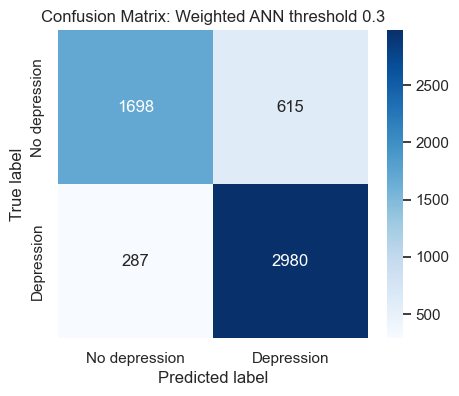


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
===== Weighted ANN threshold 0.4 =====
Threshold: 0.4
Accuracy: 0.8362007168458782
ROC AUC: 0.9122488890794515

Predicted probability summary:
count    5580.000000
mean        0.542221
std         0.373058
min         0.000545
25%         0.129326
50%         0.629559
75%         0.915669
max         0.999243
dtype: float64

Classification report:
              precision    recall  f1-score   support

         0.0       0.81      0.79      0.80      2313
         1.0       0.86      0.87      0.86      3267

    accuracy                           0.84      5580
   macro avg       0.83      0.83      0.83      5580
weighted avg       0.84      0.84      0.84      5580



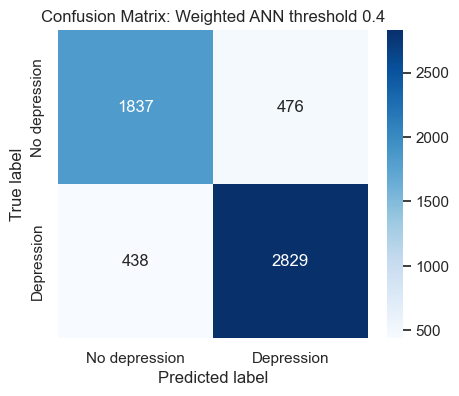


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
===== Weighted ANN threshold 0.5 =====
Threshold: 0.5
Accuracy: 0.8331541218637993
ROC AUC: 0.9122488890794515

Predicted probability summary:
count    5580.000000
mean        0.542221
std         0.373058
min         0.000545
25%         0.129326
50%         0.629559
75%         0.915669
max         0.999243
dtype: float64

Classification report:
              precision    recall  f1-score   support

         0.0       0.78      0.83      0.81      2313
         1.0       0.88      0.83      0.85      3267

    accuracy                           0.83      5580
   macro avg       0.83      0.83      0.83      5580
weighted avg       0.84      0.83      0.83      5580



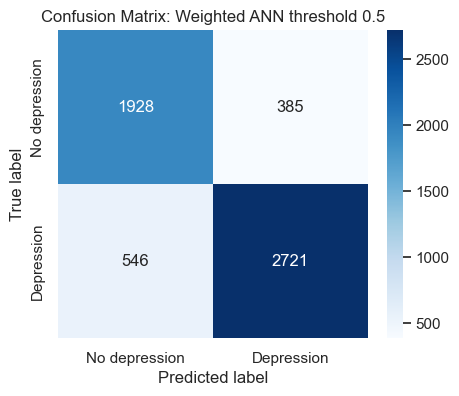


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step
===== Weighted ANN threshold 0.6 =====
Threshold: 0.6
Accuracy: 0.8234767025089605
ROC AUC: 0.9122488890794515

Predicted probability summary:
count    5580.000000
mean        0.542221
std         0.373058
min         0.000545
25%         0.129326
50%         0.629559
75%         0.915669
max         0.999243
dtype: float64

Classification report:
              precision    recall  f1-score   support

         0.0       0.74      0.87      0.80      2313
         1.0       0.90      0.79      0.84      3267

    accuracy                           0.82      5580
   macro avg       0.82      0.83      0.82      5580
weighted avg       0.83      0.82      0.82      5580



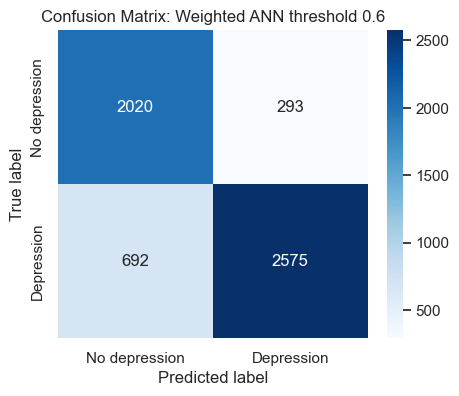


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step
===== Weighted ANN threshold 0.7 =====
Threshold: 0.7
Accuracy: 0.8064516129032258
ROC AUC: 0.9122488890794515

Predicted probability summary:
count    5580.000000
mean        0.542221
std         0.373058
min         0.000545
25%         0.129326
50%         0.629559
75%         0.915669
max         0.999243
dtype: float64

Classification report:
              precision    recall  f1-score   support

         0.0       0.71      0.91      0.80      2313
         1.0       0.92      0.73      0.82      3267

    accuracy                           0.81      5580
   macro avg       0.81      0.82      0.81      5580
weighted avg       0.83      0.81      0.81      5580



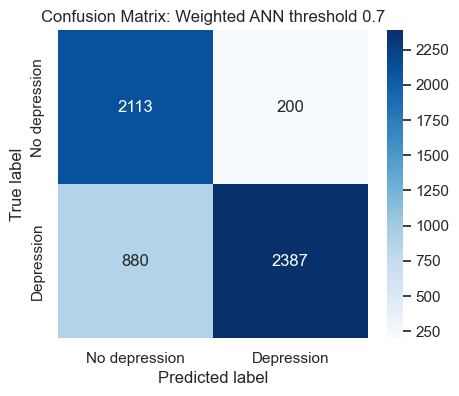

In [104]:
# =========================
# CELL 20: THRESHOLD TEST
# =========================
# Frågeställning:
# Vad händer om vi ändrar gränsen för när modellen säger "depression"?
#
# Logik:
# Default är 0.5.
# Men i mental-health-case kanske vi hellre fångar fler riskpersoner,
# även om det ger fler falska alarm.

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    print("\n==============================")
    evaluate_ann(
        f"Weighted ANN threshold {threshold}",
        ann_weighted,
        X_test_scaled,
        y_test_np,
        threshold=threshold
    )

Epoch 1/50


c:\Users\spiri\ws\mental-health-prediction\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7984 - loss: 0.4450 - val_accuracy: 0.8403 - val_loss: 0.3727
Epoch 2/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8361 - loss: 0.3797 - val_accuracy: 0.8374 - val_loss: 0.3683
Epoch 3/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8443 - loss: 0.3660 - val_accuracy: 0.8401 - val_loss: 0.3748
Epoch 4/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8461 - loss: 0.3585 - val_accuracy: 0.8374 - val_loss: 0.3739
Epoch 5/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8505 - loss: 0.3534 - val_accuracy: 0.8389 - val_loss: 0.3710
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step
===== ANN with Dropout =====
Threshold: 0.5
Accuracy: 0.8374551971326165
ROC AUC: 0.9132090468017835

Predicted probability summary:
count    5580.000000
mean        0.546973
std         0.358834
min         0.001537
25%         0.168694
50%         0.620363
75%         0.902805
max         0.999915
dtype: float64

Classificat

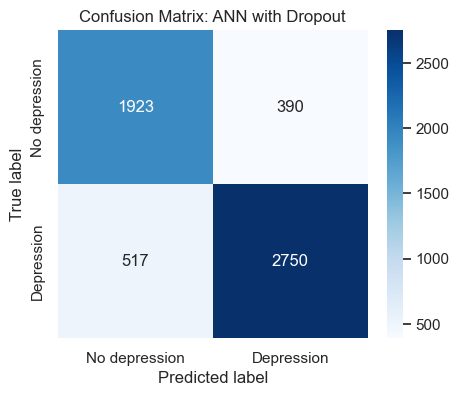

In [105]:
# =========================
# CELL 21: ANN WITH DROPOUT
# =========================
# Frågeställning:
# Kan dropout göra modellen mer robust?
#
# Logik:
# Dropout stänger av slumpmässiga neuroner under träning.
# Det minskar risken att modellen memorerar träningsdata.

from tensorflow.keras.layers import Dropout

ann_dropout = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

ann_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_dropout = ann_dropout.fit(
    X_train_scaled,
    y_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1
)

ann_results.append(
    evaluate_ann(
        "ANN with Dropout",
        ann_dropout,
        X_test_scaled,
        y_test_np,
        threshold=0.5
    )
)

,model,accuracy,roc_auc
0,Baseline ANN,0.839427,0.912933
1,ANN with Class Weights,0.833154,0.912249
2,ANN with Dropout,0.837455,0.913209


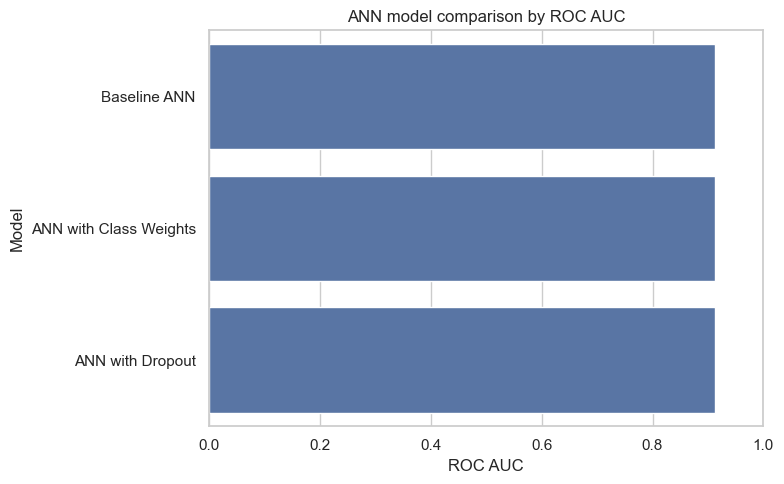

In [106]:
# =========================
# CELL 22: MODEL COMPARISON
# =========================
# Frågeställning:
# Vilken ANN-version presterar bäst?
#
# Logik:
# Vi jämför inte bara accuracy.
# ROC AUC visar om modellen faktiskt skiljer grupper bättre än slump.

ann_results_df = pd.DataFrame(ann_results)

display(ann_results_df)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=ann_results_df,
    x="roc_auc",
    y="model"
)

plt.title("ANN model comparison by ROC AUC")
plt.xlabel("ROC AUC")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

===== Logistic Regression =====
Accuracy: 0.8453405017921147
ROC AUC: 0.918315728125892
              precision    recall  f1-score   support

         0.0       0.83      0.79      0.81      2313
         1.0       0.86      0.88      0.87      3267

    accuracy                           0.85      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.84      0.85      0.84      5580



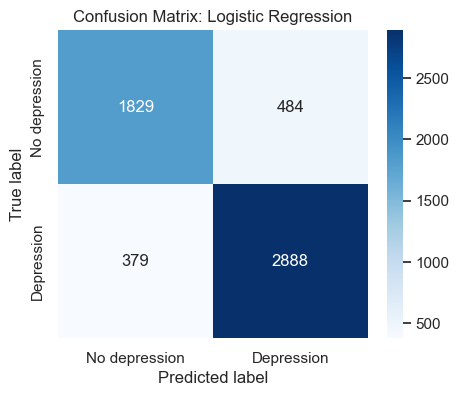

In [107]:
# =========================
# CELL 23: COMPARE ANN WITH LOGISTIC REGRESSION
# =========================
# Frågeställning:
# Behöver vi verkligen ANN, eller räcker en enklare modell?
#
# Logik:
# Logistic Regression är en stark baseline för binär klassificering.
# Om den slår ANN betyder det att datan kanske har ganska enkla linjära mönster.

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train_np)

log_proba = log_model.predict_proba(X_test_scaled)[:, 1]
log_pred = (log_proba >= 0.5).astype(int)

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test_np, log_pred))
print("ROC AUC:", roc_auc_score(y_test_np, log_proba))
print(classification_report(y_test_np, log_pred, zero_division=0))

cm = confusion_matrix(y_test_np, log_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No depression", "Depression"],
    yticklabels=["No depression", "Depression"]
)
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()